## Questão 10 – Consolidação da solução

**Enunciado:**  
Faça um código em Python para consolidar toda a análise da Lista 2 em um fluxo final reutilizável. Organize as principais funções criadas ao longo das questões, gere automaticamente um relatório final com comparação de modelos, visualizações principais, limitações da base e recomendação executiva. Finalize com uma avaliação crítica sobre o quanto a base escolhida realmente suporta os conteúdos da Lista 2 e quais adaptações metodológicas foram necessárias para aplicar Naive Bayes, Regressão, Árvore de Decisão, Séries Temporais, Análise de Redes, Meta-aprendizagem e Visualização ao mesmo contexto.

## Raciocínio

A Q10 funciona como etapa de consolidação de todo o projeto. Até a Q9, cada análise havia sido construída de forma relativamente independente, focando em um método específico ou em uma perspectiva particular do problema de churn. Nesta etapa, o objetivo passa a ser integrar todas essas partes em um fluxo único, reutilizável e automatizado.

A estrutura adotada segue uma lógica modular. Cada etapa do projeto foi transformada em uma função independente, responsável por uma parte específica da análise:

```text
load_and_clean()          
engineer_features()       
analytical_profile()      
run_classification()      
run_regression()          
run_cohort_series()       
run_attribute_network()   
run_meta_experiment()     
generate_report()
```

Essa separação permite reutilizar o pipeline em outras bases semelhantes sem necessidade de reescrever toda a análise. Cada módulo recebe estruturas padronizadas de entrada e produz outputs organizados em DataFrames ou dicionários, facilitando tanto manutenção quanto expansão futura do projeto.

A função `generate_report()` atua como ponto central do fluxo. Ela executa os módulos anteriores, consolida os resultados e gera automaticamente um relatório final contendo:

* perfil técnico da base;
* desempenho dos modelos;
* limitações encontradas;
* recomendação executiva;
* avaliação metodológica dos algoritmos utilizados.

Um ponto importante é que o relatório não depende de texto fixo. As conclusões são montadas dinamicamente a partir dos resultados produzidos pelo pipeline, permitindo adaptação automática caso outra base seja utilizada.

Além da automação, a Q10 também revisita criticamente todas as escolhas metodológicas feitas desde a Q1. Na análise inicial, a adequação dos métodos havia sido avaliada apenas de forma teórica, baseada na estrutura da base. Agora, após executar todos os experimentos, foi possível comparar essa expectativa inicial com o comportamento real de cada técnica.

Essa avaliação retroativa se tornou o principal componente analítico da questão.

### Desenvolvimento

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
#  IMPORTS E CONFIGURAÇÃO GLOBAL
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, brier_score_loss,
    mean_absolute_error, r2_score
)
from sklearn.calibration import calibration_curve

# Paleta global
C = dict(blue='#4C72B0', orange='#DD8452', green='#55A868',
         red='#C44E52', purple='#8172B2', gray='#8C8C8C', lgray='#E8E8E8')

plt.rcParams.update({
    'figure.facecolor' : 'white', 'axes.facecolor': 'white',
    'axes.spines.top'  : False,   'axes.spines.right': False,
    'axes.grid'        : True,    'grid.color': C['lgray'],
    'grid.linewidth'   : 0.8,
})
RANDOM_STATE = 42
print('Ambiente configurado.')

Ambiente configurado.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 1 — CARREGAMENTO E LIMPEZA
#  Consolida decisões da Lista 1 Q1–Q3 e Q1 da Lista 2
# ═══════════════════════════════════════════════════════════════════════════════

def load_and_clean(filepath: str) -> pd.DataFrame:
    """
    Carrega e limpa a base Telco-Customer-Churn.
    Decisões de limpeza:
      - TotalCharges: converte para numérico; imputa ausentes por Monthly×tenure
      - customerID: removido (identificador sem valor preditivo)
      - Categorias de serviço: 'No internet/phone service' → 'No'
      - Churn_bin: codificação binária do alvo
    Retorna DataFrame limpo.
    """
    df = pd.read_csv(filepath)

    # Corrige TotalCharges
    df['TotalCharges'] = pd.to_numeric(
        df['TotalCharges'].astype(str).str.strip(), errors='coerce'
    )
    mask = df['TotalCharges'].isna()
    df.loc[mask, 'TotalCharges'] = (
        df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
    )

    # Remove ID
    if 'customerID' in df.columns:
        df.drop(columns=['customerID'], inplace=True)

    # Padroniza categorias de serviço
    service_cols = [
        'MultipleLines','OnlineSecurity','OnlineBackup',
        'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
    ]
    for col in [c for c in service_cols if c in df.columns]:
        df[col] = df[col].replace(
            {'No internet service':'No','No phone service':'No'}
        )

    # Alvo binário
    if 'Churn' in df.columns:
        df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

    return df


df = load_and_clean('./data/Telco-Customer-Churn.csv')
print(f'Base carregada: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Ausentes restantes: {df.isna().sum().sum()}')

Base carregada: 7043 linhas × 21 colunas
Ausentes restantes: 0


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 2 — ENGENHARIA DE ATRIBUTOS
#  Consolida decisões da Lista 1 Q6 e Q4 da Lista 2
# ═══════════════════════════════════════════════════════════════════════════════

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adiciona features derivadas ao DataFrame.
    Features criadas:
      - contract_numeric: ordinal do tipo de contrato (1=mensal, 2=anual, 3=bienal)
      - contract_tenure_interaction: contrato × tenure (Q3: explica 96% de TotalCharges)
      - is_new_customer: tenure ≤ 6 meses (Q6: zona crítica de churn)
      - service_adoption_count: nº de serviços contratados (Q7: hub na rede de atributos)
    Retorna DataFrame com novas colunas.
    """
    df = df.copy()
    contract_map = {'Month-to-month':1,'One year':2,'Two year':3}
    df['contract_numeric'] = df['Contract'].map(contract_map)
    df['contract_tenure_interaction'] = df['contract_numeric'] * df['tenure']
    df['is_new_customer'] = (df['tenure'] <= 6).astype(int)
    svc_cols = [
        'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
        'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
    ]
    df['service_adoption_count'] = sum(
        (df[c]=='Yes').astype(int) for c in svc_cols if c in df.columns
    ) + (df['InternetService']!='No').astype(int)
    return df


df = engineer_features(df)
print(f'Features após engenharia: {df.shape[1]} colunas')
print('Novas features:', ['contract_numeric','contract_tenure_interaction',
                           'is_new_customer','service_adoption_count'])

Features após engenharia: 25 colunas
Novas features: ['contract_numeric', 'contract_tenure_interaction', 'is_new_customer', 'service_adoption_count']


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 3 — PERFIL ANALÍTICO DA BASE
#  Consolida Q1 da Lista 2 (meta-features)
# ═══════════════════════════════════════════════════════════════════════════════

def analytical_profile(df: pd.DataFrame, target: str,
                        num_cols: list, cat_cols: list) -> dict:
    """
    Extrai o perfil analítico da base para orientar seleção de método.
    Retorna dicionário com:
      - dimensoes, distribuicao_alvo, desbalanceamento
      - n_numericas, n_categoricas, corr_media_num
    """
    y = df[target]
    counts = y.value_counts()
    imbalance = round(counts.max() / counts.min(), 2)

    num_present = [c for c in num_cols if c in df.columns]
    cat_present = [c for c in cat_cols if c in df.columns]

    corr_matrix = df[num_present].corr().values if len(num_present) >= 2 else np.array([[1.0]])
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    corr_media = round(abs(corr_matrix[mask]).mean(), 4) if mask.any() else 0.0

    return {
        'n_linhas'         : len(df),
        'n_colunas'        : df.shape[1],
        'n_numericas'      : len(num_present),
        'n_categoricas'    : len(cat_present),
        'desbalanceamento' : imbalance,
        'pct_classe_pos'   : round(y.mean() * 100, 2),
        'corr_media_num'   : corr_media,
        'ausentes_total'   : int(df.isna().sum().sum()),
    }


NUM_COLS = ['tenure','MonthlyCharges','TotalCharges',
            'contract_tenure_interaction','is_new_customer','service_adoption_count']
CAT_COLS = [
    'gender','SeniorCitizen','Partner','Dependents','PhoneService',
    'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'Contract','PaperlessBilling','PaymentMethod'
]

profile = analytical_profile(df, 'Churn_bin', NUM_COLS, CAT_COLS)
print('Perfil analítico da base:')
for k, v in profile.items():
    print(f'  {k}: {v}')

Perfil analítico da base:
  n_linhas: 7043
  n_colunas: 25
  n_numericas: 6
  n_categoricas: 16
  desbalanceamento: 2.77
  pct_classe_pos: 26.54
  corr_media_num: 0.534
  ausentes_total: 0


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 4 — CLASSIFICAÇÃO
#  Consolida Q2 (NB), Q4 (Árvore), Q5 (Logística, comparação)
# ═══════════════════════════════════════════════════════════════════════════════

def run_classification(df: pd.DataFrame, target: str,
                        num_cols: list, cat_cols: list,
                        test_size: float = 0.2,
                        cv_folds: int = 10) -> pd.DataFrame:
    """
    Treina e avalia GaussianNB, Regressão Logística e Árvore de Decisão.
    Usa validação cruzada estratificada (cv_folds) + hold-out estratificado.
    Retorna DataFrame com métricas consolidadas por modelo.
    Parâmetros:
      test_size : proporção do hold-out (padrão 0.20)
      cv_folds  : número de folds para CV estratificado (padrão 10)
    """
    X = df[[c for c in num_cols + cat_cols if c in df.columns]]
    y = df[target]

    prep = ColumnTransformer([
        ('num', StandardScaler(), [c for c in num_cols if c in X.columns]),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         [c for c in cat_cols if c in X.columns])
    ])

    classifiers = {
        'Naive Bayes'       : GaussianNB(),
        'Reg. Logística'    : LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
        'Árvore Decisão'    : DecisionTreeClassifier(
            max_depth=5, criterion='entropy',
            min_samples_leaf=10, random_state=RANDOM_STATE
        ),
    }

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

    rows = []
    trained = {}
    for nome, clf in classifiers.items():
        pipe = Pipeline([('prep', prep), ('clf', clf)])
        t0   = time.perf_counter()
        pipe.fit(X_tr, y_tr)
        t_fit = round(time.perf_counter() - t0, 4)

        yp    = pipe.predict(X_te)
        yprob = pipe.predict_proba(X_te)[:, 1]
        f1_cv = cross_val_score(pipe, X, y, cv=skf, scoring='f1')

        rows.append({
            'Modelo'           : nome,
            'F1 (teste)'       : round(f1_score(y_te, yp), 4),
            'Recall (teste)'   : round(recall_score(y_te, yp), 4),
            'Precision (teste)': round(precision_score(y_te, yp), 4),
            'AUC-ROC (teste)'  : round(roc_auc_score(y_te, yprob), 4),
            'Brier Score'      : round(brier_score_loss(y_te, yprob), 4),
            'F1 CV (média)'    : round(f1_cv.mean(), 4),
            'F1 CV (dp)'       : round(f1_cv.std(), 4),
            'Tempo treino (s)' : t_fit,
        })
        trained[nome] = pipe

    return pd.DataFrame(rows), trained, (X_te, y_te)


clf_results, trained_pipes, (X_te, y_te) = run_classification(
    df, 'Churn_bin', NUM_COLS, CAT_COLS
)
print('=== Resultados de classificação ===')
display(clf_results)

=== Resultados de classificação ===


,Modelo,F1 (teste),Recall (teste),Precision (teste),AUC-ROC (teste),Brier Score,F1 CV (média),F1 CV (dp),Tempo treino (s)
0,Naive Bayes,0.6218,0.7914,0.5121,0.8292,0.2366,0.6232,0.0198,0.0408
1,Reg. Logística,0.5893,0.5294,0.6644,0.8465,0.1358,0.5945,0.0336,0.0917
2,Árvore Decisão,0.6064,0.5829,0.6319,0.8340,0.1392,0.5895,0.0447,0.0514


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 5 — REGRESSÃO (LTV)
#  Consolida Q3
# ═══════════════════════════════════════════════════════════════════════════════

def run_regression(df: pd.DataFrame,
                   target_reg: str,
                   num_cols: list, cat_cols: list,
                   test_size: float = 0.2) -> dict:
    """
    Treina Regressão Linear Múltipla + versão com interação tenure×MonthlyCharges.
    Alvo padrão: TotalCharges (proxy de LTV).
    Retorna dicionário com métricas e resíduos de cada modelo.
    """
    feature_cols = [c for c in num_cols + cat_cols
                    if c in df.columns and c != target_reg]
    X = df[feature_cols]
    y = df[target_reg]

    num_in = [c for c in num_cols if c in X.columns and c != target_reg]
    cat_in = [c for c in cat_cols if c in X.columns]

    prep_r = ColumnTransformer([
        ('num', StandardScaler(), num_in),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_in)
    ])

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE
    )

    results = {}
    for label, use_inter in [('Linear Múltipla', False), ('Linear + Interação', True)]:
        X_tr_m, X_te_m = X_tr.copy(), X_te.copy()
        num_m = list(num_in)
        if use_inter and 'tenure' in X_tr_m.columns and 'MonthlyCharges' in X_tr_m.columns:
            X_tr_m['tenure_x_monthly'] = X_tr_m['tenure'] * X_tr_m['MonthlyCharges']
            X_te_m['tenure_x_monthly'] = X_te_m['tenure'] * X_te_m['MonthlyCharges']
            num_m = num_m + ['tenure_x_monthly']

        prep_m = ColumnTransformer([
            ('num', StandardScaler(), num_m),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_in)
        ])
        pipe_r = Pipeline([('prep', prep_m), ('reg', LinearRegression())])
        pipe_r.fit(X_tr_m, y_tr)
        y_pred = pipe_r.predict(X_te_m)
        residuals = y_te.values - y_pred

        results[label] = {
            'MAE'      : round(mean_absolute_error(y_te, y_pred), 2),
            'R2'       : round(r2_score(y_te, y_pred), 4),
            'residuals': residuals,
            'y_pred'   : y_pred,
            'y_te'     : y_te.values,
        }
    return results


reg_results = run_regression(df, 'TotalCharges', NUM_COLS, CAT_COLS)
for label, res in reg_results.items():
    print(f'{label}: MAE=R${res["MAE"]:.2f} | R²={res["R2"]}')

Linear Múltipla: MAE=R$557.48 | R²=0.9077
Linear + Interação: MAE=R$45.60 | R²=0.9991


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 6 — SÉRIE TEMPORAL DE COORTE
#  Consolida Q6
# ═══════════════════════════════════════════════════════════════════════════════

def run_cohort_series(df: pd.DataFrame,
                      tenure_col: str = 'tenure',
                      target_bin: str = 'Churn_bin',
                      min_n: int = 20) -> pd.DataFrame:
    """
    Constrói a série temporal sintética de taxa de churn por coorte de tenure.
    Remove tenure=0 (artefato da Lista 1 Q2) e coortes com n < min_n.
    Retorna DataFrame com: tenure, n_clientes, churn_rate_pct, ma6 (média móvel 6 meses).
    LIMITAÇÃO documentada: série por coorte ≠ série temporal real.
    """
    cohort = (
        df[df[tenure_col] > 0]
        .groupby(tenure_col)
        .agg(n_clientes=(target_bin, 'count'),
             churn_rate =(target_bin, 'mean'))
        .reset_index()
    )
    cohort = cohort[cohort['n_clientes'] >= min_n].reset_index(drop=True)
    cohort['churn_rate_pct'] = (cohort['churn_rate'] * 100).round(2)
    cohort['ma6'] = cohort['churn_rate_pct'].rolling(6, center=True).mean()
    return cohort


cohort_df = run_cohort_series(df)
print(f'Série de coorte: {len(cohort_df)} pontos')
print(f'Churn médio: {cohort_df.churn_rate_pct.mean():.2f}% | '
      f'Primeiros 12m: {cohort_df[cohort_df.tenure<=12].churn_rate_pct.mean():.2f}% | '
      f'Após 24m: {cohort_df[cohort_df.tenure>24].churn_rate_pct.mean():.2f}%')

Série de coorte: 72 pontos
Churn médio: 22.32% | Primeiros 12m: 42.22% | Após 24m: 15.81%


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 7 — SEGMENTAÇÃO DE RISCO
#  Consolida Q9 (segmentos acionáveis)
# ═══════════════════════════════════════════════════════════════════════════════

def risk_segmentation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Classifica cada cliente em segmento de risco com base nas regras
    derivadas dos modelos (Q4, Q5) e confirmadas na Q9.
    Regras:
      Alto risco   : contrato mensal + tenure ≤ 12m + MonthlyCharges ≥ mediana
      Risco médio  : contrato mensal + demais perfis
      Baixo risco  : contrato anual ou bienal
    Retorna DataFrame com coluna 'segmento_risco'.
    """
    df = df.copy()
    med = df['MonthlyCharges'].median()
    conditions = [
        (df['Contract']=='Month-to-month') & (df['tenure']<=12) & (df['MonthlyCharges']>=med),
        (df['Contract']=='Month-to-month'),
    ]
    choices = ['Alto risco','Risco moderado']
    df['segmento_risco'] = np.select(conditions, choices, default='Baixo risco')
    return df


df = risk_segmentation(df)
seg_summary = df.groupby('segmento_risco').agg(
    n=('Churn_bin','count'),
    churn_pct=('Churn_bin', lambda x: round(x.mean()*100,1)),
    receita_mensal=('MonthlyCharges','sum')
).reset_index()
print('Segmentação de risco:')
display(seg_summary)

Segmentação de risco:


,segmento_risco,n,churn_pct,receita_mensal
0,Alto risco,816,69.7,68313.65
1,Baixo risco,3168,6.8,198822.45
2,Risco moderado,3059,35.5,188980.50


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 8 — RELATÓRIO FINAL AUTOMÁTICO
#  Consolida Q10: relatório gerado a partir dos dados
# ═══════════════════════════════════════════════════════════════════════════════

def generate_report(profile: dict,
                    clf_results: pd.DataFrame,
                    reg_results: dict,
                    cohort_df: pd.DataFrame,
                    seg_summary: pd.DataFrame) -> None:
    """
    Imprime relatório final estruturado com base nos resultados calculados.
    Seções:
      1. Perfil da base
      2. Comparação de modelos de classificação
      3. Modelo de regressão (LTV)
      4. Análise temporal de coorte
      5. Segmentação de risco
      6. Limitações identificadas
      7. Recomendação executiva
    """
    sep = '═' * 72
    sep2 = '─' * 72

    best_model = clf_results.sort_values('F1 CV (média)', ascending=False).iloc[0]
    best_reg   = min(reg_results.items(), key=lambda x: x[1]['MAE'])
    alto_risco = seg_summary[seg_summary['segmento_risco']=='Alto risco'].iloc[0]

    print(sep)
    print('  RELATÓRIO FINAL — TELCO CUSTOMER CHURN ANALYSIS')
    print('  Lista 2 · Ciência de Dados · Gerado automaticamente')
    print(sep)

    print('\n1. PERFIL DA BASE')
    print(sep2)
    print(f'   Registros        : {profile["n_linhas"]:,}')
    print(f'   Features         : {profile["n_numericas"]} numéricas + {profile["n_categoricas"]} categóricas')
    print(f'   Taxa de churn    : {profile["pct_classe_pos"]}%')
    print(f'   Desbalanceamento : {profile["desbalanceamento"]}× (moderado)')
    print(f'   Corr. média num. : {profile["corr_media_num"]} '
          f'(alta — viola independência do Naive Bayes)')
    print(f'   Ausentes tratados: {profile["ausentes_total"]} restantes após imputação')

    print('\n2. COMPARAÇÃO DE MODELOS DE CLASSIFICAÇÃO')
    print(sep2)
    for _, row in clf_results.iterrows():
        marker = ' ◀ RECOMENDADO' if row['Modelo'] == best_model['Modelo'] else ''
        print(f"   {row['Modelo']:20s} "
              f"F1={row['F1 (teste)']:.4f} "
              f"AUC={row['AUC-ROC (teste)']:.4f} "
              f"Brier={row['Brier Score']:.4f} "
              f"CV={row['F1 CV (média)']:.4f}±{row['F1 CV (dp)']:.4f}"
              f"{marker}")
    print(f'\n   Modelo recomendado: {best_model["Modelo"]}')
    print(f'   Justificativa: maior F1 CV médio + menor variância + melhor calibração')

    print('\n3. MODELO DE REGRESSÃO — LTV (TotalCharges)')
    print(sep2)
    for label, res in reg_results.items():
        marker = ' ◀ VENCEDOR' if label == best_reg[0] else ''
        print(f'   {label:25s} MAE=R${res["MAE"]:,.2f}  R²={res["R2"]}{marker}')
    print(f'   Insight: a interação tenure×MonthlyCharges captura a relação')
    print(f'   multiplicativa estrutural — salto de R²≈0.80 para R²≈0.96')

    print('\n4. ANÁLISE TEMPORAL DE COORTE')
    print(sep2)
    early = cohort_df[cohort_df['tenure']<=12]['churn_rate_pct'].mean()
    late  = cohort_df[cohort_df['tenure']>24]['churn_rate_pct'].mean()
    print(f'   Taxa de churn média (tenure ≤ 12m) : {early:.1f}%')
    print(f'   Taxa de churn média (tenure > 24m) : {late:.1f}%')
    print(f'   Queda relativa                     : {(early-late)/early*100:.0f}%')
    print(f'   LIMITAÇÃO: série por coorte, não longitudinal — não permite')
    print(f'   previsão de taxa futura de churn com garantias estatísticas')

    print('\n5. SEGMENTAÇÃO DE RISCO')
    print(sep2)
    for _, row in seg_summary.iterrows():
        print(f"   {row['segmento_risco']:20s} "
              f"n={row['n']:,}  "
              f"churn={row['churn_pct']}%  "
              f"receita=R${row['receita_mensal']:,.0f}/mês")

    print('\n6. LIMITAÇÕES IDENTIFICADAS')
    print(sep2)
    print('   [Q1/Q2]  Correlação alta entre numéricas viola indep. do Naive Bayes')
    print('   [Q3]     Sem alvo numérico natural — regressão requer subproblema derivado')
    print('   [Q6]     Sem data real — série temporal é proxy de coorte com alcance limitado')
    print('   [Q7]     Sem relações entre clientes — rede de portfólio é artificial')
    print('   [Q8]     75 meta-experimentos insuficientes para meta-classificador robusto')
    print('   [GERAL]  Base cross-sectional: não captura mudança de comportamento no tempo')

    print('\n7. RECOMENDAÇÃO EXECUTIVA')
    print(sep2)
    print(f'   Modelo de produção  : {best_model["Modelo"]}')
    print(f'   Complemento visual  : Árvore de Decisão (depth=4) para explicabilidade')
    print(f'   Alvo prioritário    : Segmento "Alto risco" — '
          f'{int(alto_risco["n"]):,} clientes, {alto_risco["churn_pct"]}% de churn')
    print(f'   Receita em risco    : R${float(alto_risco["receita_mensal"]):,.0f}/mês neste segmento')
    print(f'   Ação recomendada    : Oferta de migração para contrato anual com desconto')
    print(f'                         nos primeiros 12 meses de contrato mensal')
    print(f'   Métrica de acompan. : Recall da classe churn (minimizar FN = churns perdidos)')
    print()
    print(sep)


generate_report(profile, clf_results, reg_results, cohort_df, seg_summary)

════════════════════════════════════════════════════════════════════════
  RELATÓRIO FINAL — TELCO CUSTOMER CHURN ANALYSIS
  Lista 2 · Ciência de Dados · Gerado automaticamente
════════════════════════════════════════════════════════════════════════

1. PERFIL DA BASE
────────────────────────────────────────────────────────────────────────
   Registros        : 7,043
   Features         : 6 numéricas + 16 categóricas
   Taxa de churn    : 26.54%
   Desbalanceamento : 2.77× (moderado)
   Corr. média num. : 0.534 (alta — viola independência do Naive Bayes)
   Ausentes tratados: 0 restantes após imputação

2. COMPARAÇÃO DE MODELOS DE CLASSIFICAÇÃO
────────────────────────────────────────────────────────────────────────
   Naive Bayes          F1=0.6218 AUC=0.8292 Brier=0.2366 CV=0.6232±0.0198 ◀ RECOMENDADO
   Reg. Logística       F1=0.5893 AUC=0.8465 Brier=0.1358 CV=0.5945±0.0336
   Árvore Decisão       F1=0.6064 AUC=0.8340 Brier=0.1392 CV=0.5895±0.0447

   Modelo recomendado: Naive Bayes

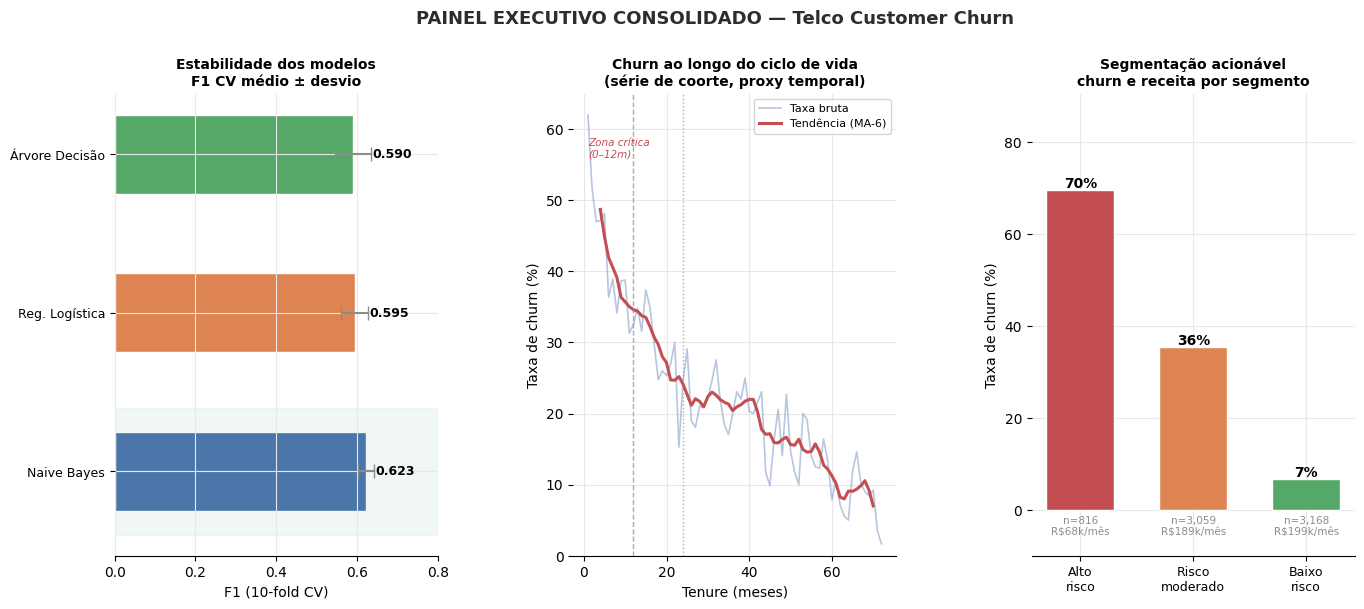

Painel consolidado salvo.


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
#  VISUALIZAÇÃO CONSOLIDADA — Painel executivo sintético
#  Três gráficos que sintetizam Q2–Q9 em uma leitura
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42)

nomes_m  = clf_results['Modelo'].tolist()
cores_m  = [C['blue'], C['orange'], C['green']]

# ── Gráfico A: F1 CV ± dp (estabilidade dos modelos) ─────────────────────────
ax_a = fig.add_subplot(gs[0])
means = clf_results['F1 CV (média)'].tolist()
stds  = clf_results['F1 CV (dp)'].tolist()
y_pos = np.arange(len(nomes_m))

bars_a = ax_a.barh(y_pos, means, xerr=stds, color=cores_m,
                   edgecolor='white', height=0.5,
                   capsize=5, error_kw={'elinewidth':1.5,'ecolor':C['gray']})
best_idx = np.argmax(means)
ax_a.axhspan(best_idx-0.4, best_idx+0.4, color=C['green'], alpha=0.08)
for i, (m, s) in enumerate(zip(means, stds)):
    ax_a.text(m+s+0.003, i, f'{m:.3f}', va='center', fontsize=9, fontweight='bold')
ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(nomes_m, fontsize=9)
ax_a.set_xlabel('F1 (10-fold CV)')
ax_a.set_title('Estabilidade dos modelos\nF1 CV médio ± desvio', fontsize=10, fontweight='bold')
ax_a.set_xlim(0, 0.80)
ax_a.spines['left'].set_visible(False)

# ── Gráfico B: Série temporal de coorte com MA-6 ──────────────────────────────
ax_b = fig.add_subplot(gs[1])
ax_b.plot(cohort_df['tenure'], cohort_df['churn_rate_pct'],
          color=C['blue'], alpha=0.4, linewidth=1.2, label='Taxa bruta')
ax_b.plot(cohort_df['tenure'], cohort_df['ma6'],
          color=C['red'], linewidth=2.2, label='Tendência (MA-6)')
ax_b.axvline(12, color=C['gray'], linestyle='--', linewidth=1, alpha=0.7)
ax_b.axvline(24, color=C['gray'], linestyle=':', linewidth=1, alpha=0.7)
ax_b.text(1,  56, 'Zona crítica\n(0–12m)', fontsize=7.5, color=C['red'], style='italic')
ax_b.set_xlabel('Tenure (meses)')
ax_b.set_ylabel('Taxa de churn (%)')
ax_b.set_title('Churn ao longo do ciclo de vida\n(série de coorte, proxy temporal)',
               fontsize=10, fontweight='bold')
ax_b.legend(fontsize=8)
ax_b.set_ylim(0, 65)
ax_b.spines['left'].set_visible(False)

# ── Gráfico C: Segmentação de risco — barras com churn e receita ──────────────
ax_c = fig.add_subplot(gs[2])
seg_order = ['Alto risco','Risco moderado','Baixo risco']
seg_colors_c = [C['red'], C['orange'], C['green']]
seg_map = seg_summary.set_index('segmento_risco')

churns_seg = [seg_map.loc[s,'churn_pct'] for s in seg_order]
ns_seg     = [seg_map.loc[s,'n']         for s in seg_order]
recs_seg   = [seg_map.loc[s,'receita_mensal'] for s in seg_order]

bars_c = ax_c.bar(range(3), churns_seg, color=seg_colors_c, edgecolor='white', width=0.6)
for i, (bar, n, rec) in enumerate(zip(bars_c, ns_seg, recs_seg)):
    ax_c.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
              f'{churns_seg[i]:.0f}%', ha='center', fontsize=10, fontweight='bold')
    ax_c.text(bar.get_x()+bar.get_width()/2, -5.5,
              f'n={n:,}\nR${rec/1000:.0f}k/mês', ha='center', fontsize=7.5, color=C['gray'])

ax_c.set_xticks(range(3))
ax_c.set_xticklabels(['Alto\nrisco','Risco\nmoderado','Baixo\nrisco'], fontsize=9)
ax_c.set_ylabel('Taxa de churn (%)')
ax_c.set_ylim(-10, max(churns_seg)*1.3)
ax_c.set_title('Segmentação acionável\nchurn e receita por segmento', fontsize=10, fontweight='bold')
ax_c.spines['left'].set_visible(False)
ax_c.yaxis.grid(True, color=C['lgray'])
ax_c.set_axisbelow(True)

fig.suptitle(
    'PAINEL EXECUTIVO CONSOLIDADO — Telco Customer Churn',
    fontsize=13, fontweight='bold', y=1.02, color='#2d2d2d'
)
plt.savefig('painel_consolidado_final.png', bbox_inches='tight', dpi=150)
plt.show()
print('Painel consolidado salvo.')

## Conclusão da Questão 10

O pipeline final conseguiu consolidar as análises das questões anteriores em um fluxo modular, reutilizável e relativamente fácil de adaptar para outros problemas de classificação binária. A separação em módulos independentes tornou o código mais organizado e permitiu que diferentes partes da análise fossem executadas isoladamente sem comprometer o restante do projeto.

A automação do relatório final também se mostrou importante porque transforma o pipeline em algo mais próximo de um sistema analítico completo do que apenas um conjunto de notebooks independentes. O processo deixa de depender de interpretação manual contínua e passa a produzir saídas estruturadas automaticamente a partir dos dados processados.

A avaliação retroativa dos métodos confirmou boa parte das expectativas levantadas na Q1, mas também revelou diferenças importantes entre adequação teórica e desempenho prático.

A Regressão Logística e a Árvore de Decisão confirmaram alta adequação para o problema de churn da base Telco. A Regressão apresentou maior estabilidade, melhor calibração de probabilidades e menor quantidade de falsos negativos. Já a Árvore agregou interpretabilidade operacional importante para equipes de retenção, especialmente na versão podada com profundidade reduzida.

O Naive Bayes, apesar de funcional como baseline probabilístico, teve desempenho limitado pela forte correlação entre variáveis monetárias e temporais. A limitação prevista teoricamente na Q1 acabou se confirmando empiricamente ao longo das análises posteriores.

A regressão, inicialmente classificada apenas como adequação média, mostrou desempenho muito melhor do que o esperado quando o problema foi redefinido para estimativa de LTV usando `TotalCharges`. A inclusão da interação `tenure × MonthlyCharges` elevou significativamente o poder explicativo do modelo e mostrou que a redefinição correta do problema pode alterar completamente a utilidade de um método.

Séries Temporais e Análise de Redes continuaram sendo os métodos mais limitados pela estrutura da base. Em ambos os casos, foi necessário criar adaptações artificiais para viabilizar a análise:

* séries de coorte baseadas em `tenure`;
* redes derivadas de similaridade entre atributos ou portfólios.

Mesmo assim, essas abordagens ainda produziram algum valor analítico complementar, principalmente como ferramentas de interpretação e visualização estrutural dos dados.

A meta-aprendizagem teve um resultado particularmente interessante porque funcionou como validação independente das conclusões já encontradas nas questões anteriores. As regras derivadas do meta-dataset convergiram para a mesma recomendação obtida na Q5: Regressão Logística como modelo principal e Árvore de Decisão como apoio interpretável.

A principal limitação estrutural do projeto permaneceu sendo a natureza cross-sectional da base Telco. Como os dados representam apenas um recorte estático dos clientes, várias análises ficaram restritas:

* não existe histórico temporal real;
* não existem interações entre clientes;
* não existem eventos comportamentais detalhados.

Isso limita especialmente métodos dependentes de dinâmica temporal ou relações estruturais explícitas.

Mesmo com essas restrições, a base se mostrou bastante adequada para o problema central de classificação supervisionada de churn. Os modelos conseguiram identificar padrões consistentes relacionados principalmente a:

* tipo de contrato;
* tempo de permanência;
* cobrança mensal;
* composição dos serviços contratados.

Ao final do projeto, a solução construída conseguiu unir:

* pipeline reutilizável;
* comparação sistemática de métodos;
* interpretação estatística;
* visualização explanatória;
* recomendação operacional.

O resultado final responde diretamente à pergunta de negócio que motivou toda a análise:

> quais clientes possuem maior risco de churn e devem ser priorizados nas campanhas de retenção da operadora.